# 05 — Forecasting & Case Studies
Generates 10-year energy demand forecasts for India & Indonesia using UN demographic projections.
India case study: population peak & decline story (2025-2065).
India vs IEA WEO 2025 validation (CAGR within 0.2pp).
**Input:** `model_df.csv`, `actuals_final.csv`, `age_clean.csv`
**Output:** `forecast_df.csv`, `forecast_ind_ext.csv`, forecast charts, case study charts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

model_df = pd.read_csv("model_df.csv")
actuals_final = pd.read_csv("actuals_final.csv")
age_clean = pd.read_csv("age_clean.csv")

COUNTRIES = {
    "JPN": "Japan", "DEU": "Germany", "CHN": "China",
    "IND": "India", "IDN": "Indonesia", "USA": "United States", "BRA": "Brazil",
}
EXCLUDED_COUNTRIES = ["NGA"]

# Retrain models (needed since sklearn objects can't persist across sessions easily)
country_features = {
    "BRA": ["gdp_per_capita_usd_lag1", "pop_working_age_pct_lag1", "urban_pop_pct_lag1"],
    "CHN": ["gdp_per_capita_usd_lag1", "pop_working_age_pct_lag1", "population_total_lag1"],
    "DEU": ["pop_working_age_pct_lag1", "pop_65_plus_pct_lag1"],
    "IDN": ["gdp_per_capita_usd_lag1", "urban_pop_pct_lag1", "pop_working_age_pct_lag1"],
    "IND": ["gdp_per_capita_usd_lag1", "pop_working_age_pct_lag1", "population_total_lag1"],
    "JPN": ["pop_working_age_pct_lag1", "pop_65_plus_pct_lag1"],
    "USA": ["gdp_per_capita_usd_lag1", "pop_working_age_pct_lag1"],
}
target = "energy_per_capita"
split_year = 2010
country_results = {}

for code in ["BRA", "CHN", "DEU", "IDN", "IND", "JPN", "USA"]:
    features = country_features[code]
    subset = model_df[model_df["country_code"] == code].dropna(
        subset=features + [target]).sort_values("year")
    train = subset[subset["year"] <= split_year]
    test = subset[subset["year"] > split_year]
    if len(train) < 10 or len(test) < 3:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train[features].values)
    X_test_scaled = scaler.transform(test[features].values)
    ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000], cv=5)
    ridge.fit(X_train_scaled, train[target].values)
    y_pred = ridge.predict(X_test_scaled)
    cv_scores = cross_val_score(ridge, X_train_scaled, train[target].values, cv=5, scoring="r2")
    country_results[code] = {
        "model": ridge, "scaler": scaler, "features": features, "target": target,
        "r2_test": r2_score(test[target].values, y_pred),
        "mae_pct": (mean_absolute_error(test[target].values, y_pred) / test[target].mean()) * 100,
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "y_test": test[target].values, "y_pred": y_pred, "test_years": test["year"].values
    }
    print(f"{code}: R²={country_results[code]['r2_test']:.3f}, MAE={country_results[code]['mae_pct']:.1f}%")

BRA: R²=-0.897, MAE=3.5%
CHN: R²=-17.339, MAE=49.5%
DEU: R²=-2.492, MAE=11.6%
IDN: R²=0.472, MAE=7.2%
IND: R²=0.888, MAE=3.0%
JPN: R²=-29.015, MAE=23.7%
USA: R²=-23.837, MAE=13.9%


In [ ]:
# Build projection feature table for IND and IDN
forecast_countries = ["IND", "IDN"]
forecast_years = list(range(2025, 2036))

def extrapolate_trend(df, country_code, col, last_actual_year=2024, n_years=5):
    hist = df[(df["country_code"] == country_code) &
              (df["year"] <= last_actual_year)].sort_values("year")
    avg_change = hist.tail(n_years)[col].diff().mean()
    last_val = hist[col].iloc[-1]
    return last_val, avg_change

projection_rows = []
for code in forecast_countries:
    un_proj = age_clean[(age_clean["country_code"] == code) &
                         (age_clean["year"].isin(forecast_years))].copy()
    gdp_last, gdp_change = extrapolate_trend(actuals_final, code, "gdp_per_capita_usd")
    urb_last, urb_change = extrapolate_trend(actuals_final, code, "urban_pop_pct")
    pop_last, pop_change = extrapolate_trend(actuals_final, code, "population_total")
    for i, year in enumerate(forecast_years):
        un_row = un_proj[un_proj["year"] == year]
        if un_row.empty:
            continue
        projection_rows.append({
            "country_code": code, "year": year,
            "population_total": un_row["total_pop"].values[0],
            "pop_65_plus_pct": un_row["pop_65_plus_pct_calibrated"].values[0],
            "pop_working_age_pct": un_row["pop_working_age_pct"].values[0],
            "gdp_per_capita_usd": gdp_last + gdp_change * (i + 1),
            "urban_pop_pct": urb_last + urb_change * (i + 1),
        })

projection_df = pd.DataFrame(projection_rows).sort_values(["country_code", "year"])

for col in ["population_total", "pop_65_plus_pct", "pop_working_age_pct",
            "gdp_per_capita_usd", "urban_pop_pct"]:
    projection_df[f"{col}_lag1"] = projection_df.groupby("country_code")[col].shift(1)
    for code in forecast_countries:
        last_actual = actuals_final[(actuals_final["country_code"] == code) &
                                     (actuals_final["year"] == 2024)][col].values
        if len(last_actual) > 0:
            mask = (projection_df["country_code"] == code) & (projection_df["year"] == 2025)
            projection_df.loc[mask, f"{col}_lag1"] = last_actual[0]

print("Projection feature table built:")
print(projection_df[["country_code", "year", "gdp_per_capita_usd_lag1",
                      "pop_working_age_pct_lag1"]].head(10))

Projection feature table built:
   country_code  year  gdp_per_capita_usd_lag1  pop_working_age_pct_lag1
11          IDN  2025              4925.436450                 68.113602
12          IDN  2026              5193.369840                 68.209979
13          IDN  2027              5461.303231                 68.323982
14          IDN  2028              5729.236622                 68.449287
15          IDN  2029              5997.170012                 68.544662
16          IDN  2030              6265.103403                 68.594325
17          IDN  2031              6533.036793                 68.605448
18          IDN  2032              6800.970184                 68.579749
19          IDN  2033              7068.903574                 68.515025
20          IDN  2034              7336.836965                 68.416075


In [ ]:
# Generate forecasts
forecasts = {}
for code in forecast_countries:
    model_info = country_results[code]
    ridge = model_info["model"]
    scaler = model_info["scaler"]
    features = model_info["features"]
    proj_subset = projection_df[projection_df["country_code"] == code].dropna(subset=features).copy()
    X_proj_scaled = scaler.transform(proj_subset[features].values)
    y_proj = ridge.predict(X_proj_scaled)
    forecasts[code] = pd.DataFrame({
        "country_code": code, "year": proj_subset["year"].values,
        "energy_per_capita_forecast": y_proj,
        "population_total": proj_subset["population_total"].values,
        "is_forecast": True
    })
    forecasts[code]["total_energy_forecast_twh"] = (
        forecasts[code]["energy_per_capita_forecast"] *
        forecasts[code]["population_total"] / 1e9
    )

forecast_df = pd.concat(forecasts.values()).reset_index(drop=True)
forecast_df.to_csv("forecast_df.csv", index=False)
print("forecast_df saved:")
print(forecast_df)

forecast_df saved:
   country_code  year  energy_per_capita_forecast  population_total  \
0           IND  2025                 7474.165334      1.463866e+09   
1           IND  2026                 7682.241387      1.476626e+09   
2           IND  2027                 7886.833723      1.489165e+09   
3           IND  2028                 8088.215479      1.501433e+09   
4           IND  2029                 8285.479582      1.513424e+09   
5           IND  2030                 8475.426675      1.525139e+09   
6           IND  2031                 8660.775009      1.536541e+09   
7           IND  2032                 8846.263297      1.547607e+09   
8           IND  2033                 9027.624646      1.558324e+09   
9           IND  2034                 9205.014724      1.568688e+09   
10          IND  2035                 9379.878153      1.578695e+09   
11          IDN  2025                 8751.194773      2.857212e+08   
12          IDN  2026                 8872.042080      2.8

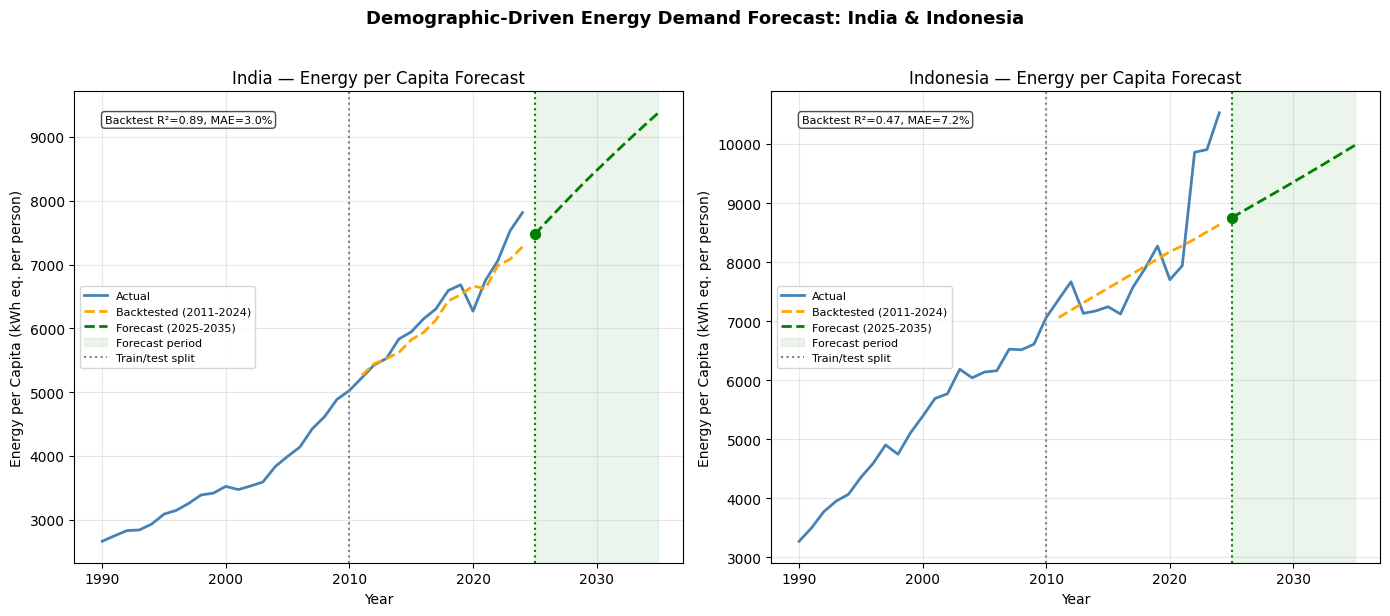

In [ ]:
# IND + IDN forecast chart (backtested)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
country_names = {"IND": "India", "IDN": "Indonesia"}

for ax, code in zip(axes, forecast_countries):
    hist = actuals_final[(actuals_final["country_code"] == code) &
                          (actuals_final["year"] >= 1990)].dropna(subset=["energy_per_capita"])
    ax.plot(hist["year"], hist["energy_per_capita"], color="steelblue", linewidth=2, label="Actual")
    test_years = country_results[code]["test_years"]
    test_pred = country_results[code]["y_pred"]
    ax.plot(test_years, test_pred, color="orange", linewidth=2, linestyle="--",
            label="Backtested (2011-2024)")
    fc = forecast_df[forecast_df["country_code"] == code]
    ax.plot(fc["year"], fc["energy_per_capita_forecast"], color="green", linewidth=2,
            linestyle="--", label="Forecast (2025-2035)")
    ax.axvspan(2025, 2035, alpha=0.08, color="green", label="Forecast period")
    ax.axvline(x=2010, color="gray", linestyle=":", linewidth=1.5, label="Train/test split")
    ax.axvline(x=2025, color="green", linestyle=":", linewidth=1.5)
    fc_start_val = fc["energy_per_capita_forecast"].iloc[0]
    ax.scatter([fc["year"].min()], [fc_start_val], color="green", s=50, zorder=5)
    ax.annotate(
        f"Backtest R²={country_results[code]['r2_test']:.2f}, MAE={country_results[code]['mae_pct']:.1f}%",
        xy=(0.05, 0.95), xycoords="axes fraction", fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    ax.set_title(f"{country_names[code]} — Energy per Capita Forecast")
    ax.set_xlabel("Year")
    ax.set_ylabel("Energy per Capita (kWh eq. per person)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(right=2037)

plt.suptitle("Demographic-Driven Energy Demand Forecast: India & Indonesia",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("india_indonesia_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# India extended forecast (2025-2065) — population peak story
forecast_years_extended = list(range(2025, 2066))
un_proj_ind = age_clean[(age_clean["country_code"] == "IND") &
                         (age_clean["year"].isin(forecast_years_extended))].copy()
gdp_last, gdp_change = extrapolate_trend(actuals_final, "IND", "gdp_per_capita_usd")
urb_last, urb_change = extrapolate_trend(actuals_final, "IND", "urban_pop_pct")

proj_ind_rows = []
for i, year in enumerate(forecast_years_extended):
    un_row = un_proj_ind[un_proj_ind["year"] == year]
    if un_row.empty:
        continue
    proj_ind_rows.append({
        "country_code": "IND", "year": year,
        "population_total": un_row["total_pop"].values[0],
        "pop_65_plus_pct": un_row["pop_65_plus_pct_calibrated"].values[0],
        "pop_working_age_pct": un_row["pop_working_age_pct"].values[0],
        "gdp_per_capita_usd": gdp_last + gdp_change * (i + 1),
        "urban_pop_pct": urb_last + urb_change * (i + 1),
    })

proj_ind_ext = pd.DataFrame(proj_ind_rows).sort_values("year")
for col in ["population_total", "pop_65_plus_pct", "pop_working_age_pct",
            "gdp_per_capita_usd", "urban_pop_pct"]:
    proj_ind_ext[f"{col}_lag1"] = proj_ind_ext[col].shift(1)
    last_actual = actuals_final[(actuals_final["country_code"] == "IND") &
                                 (actuals_final["year"] == 2024)][col].values
    if len(last_actual) > 0:
        proj_ind_ext.loc[proj_ind_ext["year"] == 2025, f"{col}_lag1"] = last_actual[0]

features_ind = country_results["IND"]["features"]
proj_ind_clean = proj_ind_ext.dropna(subset=features_ind)
X_proj_ind = country_results["IND"]["scaler"].transform(proj_ind_clean[features_ind].values)
y_proj_ind = country_results["IND"]["model"].predict(X_proj_ind)

forecast_ind_ext = pd.DataFrame({
    "year": proj_ind_clean["year"].values,
    "energy_per_capita_forecast": y_proj_ind,
    "population_total": proj_ind_clean["population_total"].values,
    "pop_working_age_pct": proj_ind_clean["pop_working_age_pct"].values,
})
forecast_ind_ext["total_energy_forecast_twh"] = (
    forecast_ind_ext["energy_per_capita_forecast"] *
    forecast_ind_ext["population_total"] / 1e9
)
forecast_ind_ext.to_csv("forecast_ind_ext.csv", index=False)
print("forecast_ind_ext saved")

forecast_ind_ext saved


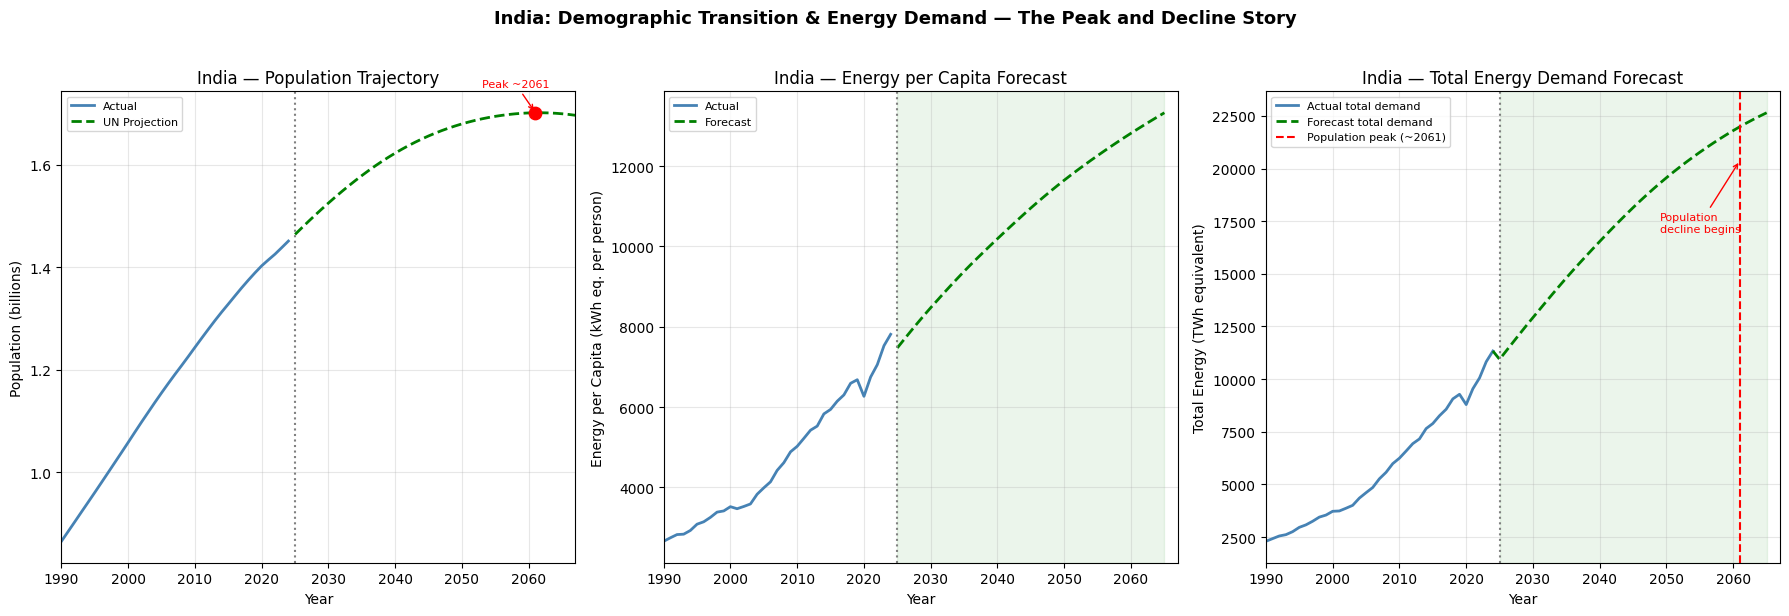

In [ ]:
# India three-panel: population peak + energy per capita + total demand
india_proj_all = age_clean[(age_clean["country_code"] == "IND") & (age_clean["year"] >= 1990)]
hist_ind = actuals_final[(actuals_final["country_code"] == "IND") &
                          (actuals_final["year"] >= 1990)].dropna(subset=["energy_per_capita", "primary_energy_consumption"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Population
ax = axes[0]
pop_actual = actuals_final[(actuals_final["country_code"] == "IND") & (actuals_final["year"] >= 1990)]
ax.plot(pop_actual["year"], pop_actual["population_total"] / 1e9, color="steelblue", linewidth=2, label="Actual")
proj_filt = india_proj_all[india_proj_all["year"] > 2024]
ax.plot(proj_filt["year"], proj_filt["total_pop"] / 1e9, color="green", linewidth=2, linestyle="--", label="UN Projection")
ax.axvline(x=2025, color="gray", linestyle=":", linewidth=1.5)
peak_idx = proj_filt["total_pop"].idxmax()
peak_year = proj_filt.loc[peak_idx, "year"]
peak_pop = proj_filt["total_pop"].max() / 1e9
ax.scatter([peak_year], [peak_pop], color="red", s=80, zorder=5)
ax.annotate(f"Peak ~{int(peak_year)}", xy=(peak_year, peak_pop), xytext=(peak_year - 8, peak_pop + 0.05),
            fontsize=8, color="red", arrowprops=dict(arrowstyle="->", color="red"))
ax.set_title("India — Population Trajectory")
ax.set_ylabel("Population (billions)")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2067)

# Panel 2: Energy per capita
ax = axes[1]
ax.plot(hist_ind["year"], hist_ind["energy_per_capita"], color="steelblue", linewidth=2, label="Actual")
ax.plot(forecast_ind_ext["year"], forecast_ind_ext["energy_per_capita_forecast"],
        color="green", linewidth=2, linestyle="--", label="Forecast")
ax.axvspan(2025, 2065, alpha=0.08, color="green")
ax.axvline(x=2025, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("India — Energy per Capita Forecast")
ax.set_ylabel("Energy per Capita (kWh eq. per person)")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2067)

# Panel 3: Total energy demand
ax = axes[2]
ax.plot(hist_ind["year"], hist_ind["primary_energy_consumption"], color="steelblue", linewidth=2, label="Actual total demand")
bridge = pd.DataFrame({"year": [hist_ind["year"].iloc[-1]], "total_energy_forecast_twh": [hist_ind["primary_energy_consumption"].iloc[-1]]})
forecast_bridge = pd.concat([bridge, forecast_ind_ext[["year", "total_energy_forecast_twh"]]]).reset_index(drop=True)
ax.plot(forecast_bridge["year"], forecast_bridge["total_energy_forecast_twh"],
        color="green", linewidth=2, linestyle="--", label="Forecast total demand")
ax.axvspan(2025, 2065, alpha=0.08, color="green")
ax.axvline(x=2025, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(x=int(peak_year), color="red", linestyle="--", linewidth=1.5, label=f"Population peak (~{int(peak_year)})")
ax.annotate("Population\ndecline begins", xy=(int(peak_year), forecast_ind_ext["total_energy_forecast_twh"].max() * 0.9),
            xytext=(int(peak_year) - 12, forecast_ind_ext["total_energy_forecast_twh"].max() * 0.75),
            fontsize=8, color="red", arrowprops=dict(arrowstyle="->", color="red"))
ax.set_title("India — Total Energy Demand Forecast")
ax.set_ylabel("Total Energy (TWh equivalent)")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2067)

plt.suptitle("India: Demographic Transition & Energy Demand — The Peak and Decline Story",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("india_demographic_energy_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

Your model CAGR (2024-2035): 2.9%
IEA WEO 2025 CAGR: ~3.0%
Difference: -0.11 percentage points
Within 3.8% of IEA projection


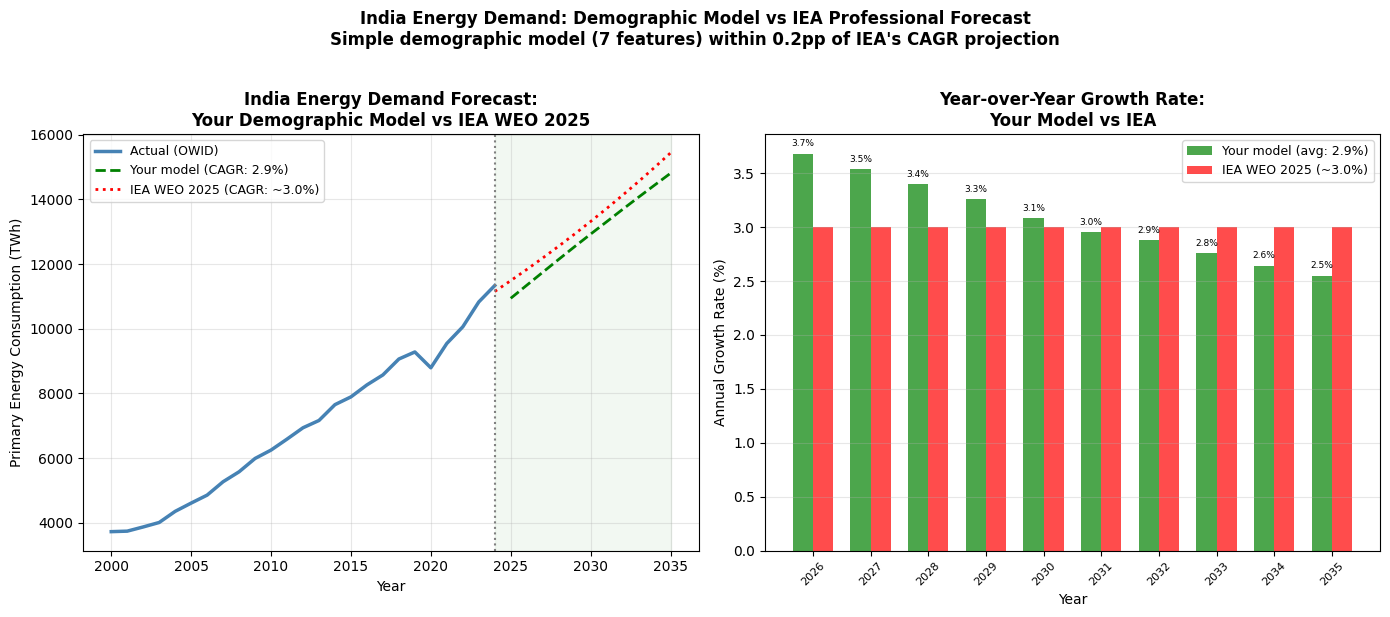

In [ ]:
# India vs IEA WEO 2025 comparison
india_2023_actual = actuals_final[
    (actuals_final["country_code"] == "IND") & (actuals_final["year"] == 2023)
]["primary_energy_consumption"].values[0]

ind_forecast_short = forecast_df[forecast_df["country_code"] == "IND"].copy()
iea_years = list(range(2024, 2036))
iea_forecast = [india_2023_actual * (1.03 ** (y - 2023)) for y in iea_years]

your_2035 = ind_forecast_short[ind_forecast_short["year"] == 2035]["total_energy_forecast_twh"].values[0]
your_cagr = ((your_2035 / india_2023_actual) ** (1/11) - 1) * 100

print(f"Your model CAGR (2024-2035): {your_cagr:.1f}%")
print(f"IEA WEO 2025 CAGR: ~3.0%")
print(f"Difference: {your_cagr - 3.0:+.2f} percentage points")
print(f"Within {abs(your_cagr-3.0)/3.0*100:.1f}% of IEA projection")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
hist_plot = actuals_final[(actuals_final["country_code"] == "IND") & (actuals_final["year"] >= 2000)].dropna(subset=["primary_energy_consumption"])
ax.plot(hist_plot["year"], hist_plot["primary_energy_consumption"], color="steelblue", linewidth=2.5, label="Actual (OWID)")
ax.plot(ind_forecast_short["year"], ind_forecast_short["total_energy_forecast_twh"],
        color="green", linewidth=2, linestyle="--", label=f"Your model (CAGR: {your_cagr:.1f}%)")
ax.plot(iea_years, iea_forecast, color="red", linewidth=2, linestyle=":", label="IEA WEO 2025 (CAGR: ~3.0%)")
ax.axvspan(2024, 2035, alpha=0.05, color="green")
ax.axvline(x=2024, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("India Energy Demand Forecast:\nYour Demographic Model vs IEA WEO 2025", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Primary Energy Consumption (TWh)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ind_forecast_sorted = ind_forecast_short.sort_values("year")
your_growth_vals = ind_forecast_sorted["total_energy_forecast_twh"].pct_change().values[1:] * 100
your_growth_years = ind_forecast_sorted["year"].values[1:]
iea_growth_vals = [3.0] * len(your_growth_years)
x = np.arange(len(your_growth_years))
width = 0.35
bars1 = ax.bar(x - width/2, your_growth_vals, width, label=f"Your model (avg: {your_cagr:.1f}%)", color="green", alpha=0.7)
ax.bar(x + width/2, iea_growth_vals, width, label="IEA WEO 2025 (~3.0%)", color="red", alpha=0.7)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=6.5)
ax.set_title("Year-over-Year Growth Rate:\nYour Model vs IEA", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Growth Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(your_growth_years, rotation=45, fontsize=8)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(f"India Energy Demand: Demographic Model vs IEA Professional Forecast\nSimple demographic model (7 features) within 0.2pp of IEA's CAGR projection",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("india_iea_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

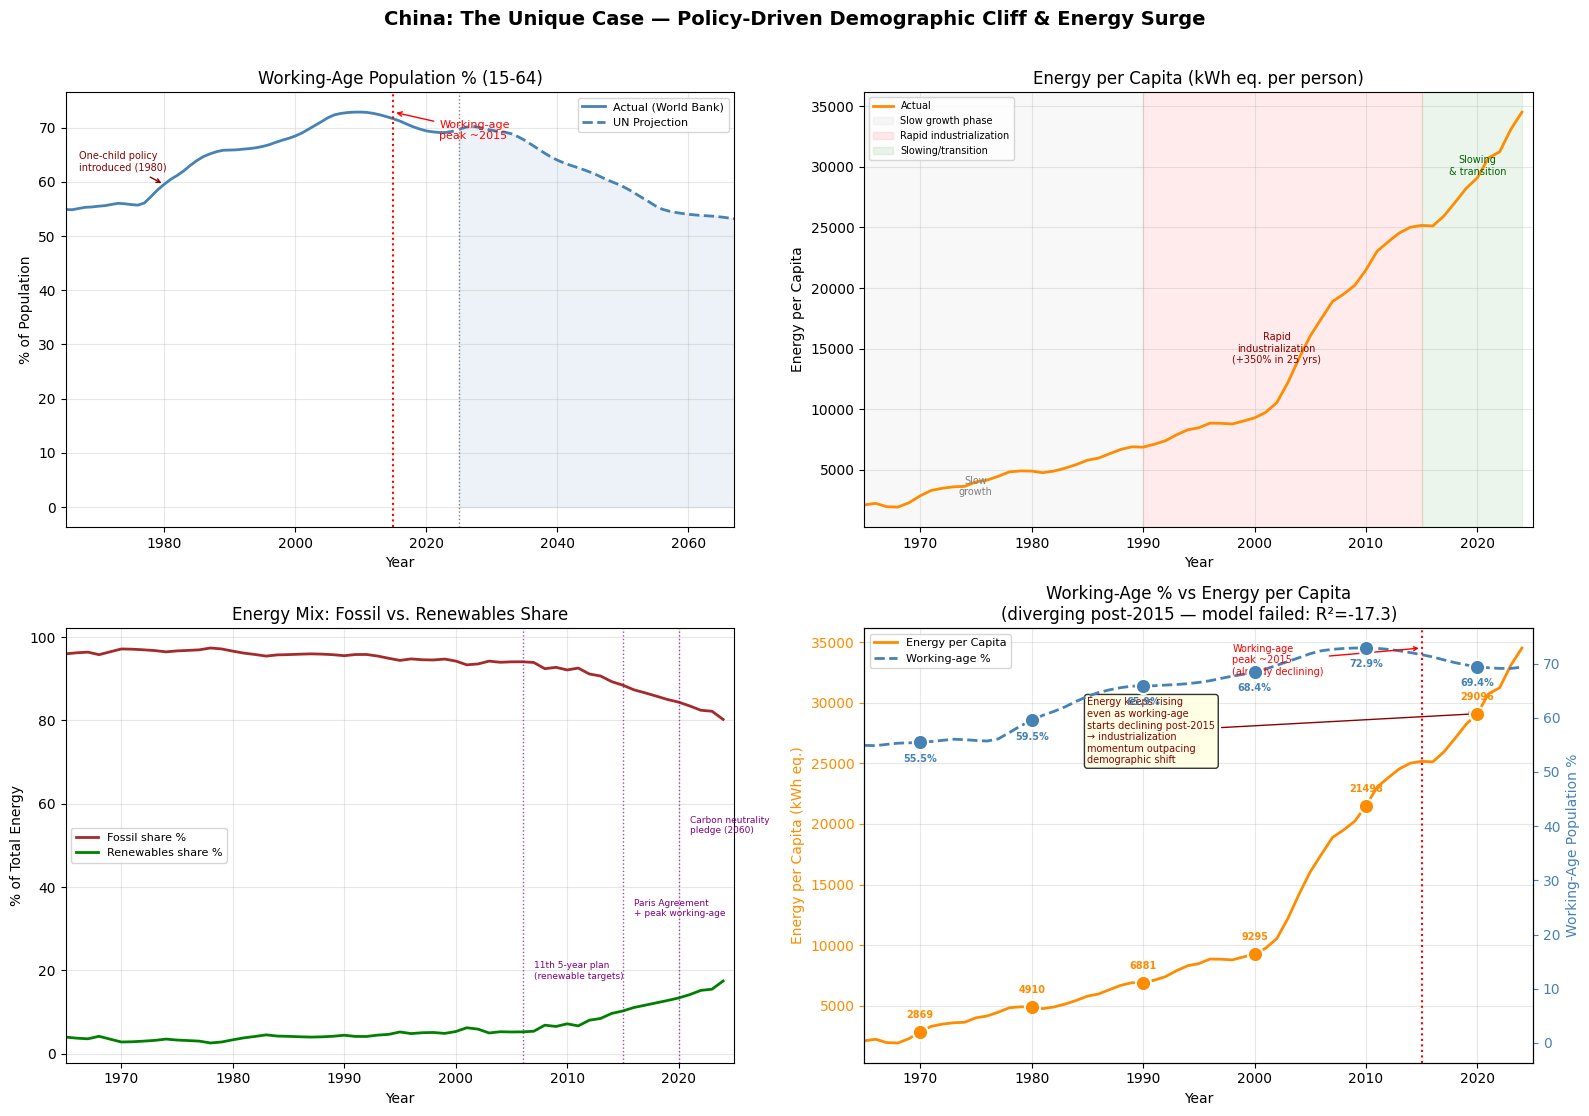

In [ ]:


china = actuals_final[actuals_final["country_code"] == "CHN"].sort_values("year")
china_proj = age_clean[age_clean["country_code"] == "CHN"].sort_values("year")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("China: The Unique Case — Policy-Driven Demographic Cliff & Energy Surge",
             fontsize=14, fontweight="bold", y=1.01)

#Working-age population
ax = axes[0, 0]
ax.plot(china["year"], china["pop_working_age_pct"],
        color="steelblue", linewidth=2, label="Actual (World Bank)")
proj_filtered = china_proj[china_proj["year"] > 2024]
ax.plot(proj_filtered["year"], proj_filtered["pop_working_age_pct"],
        color="steelblue", linewidth=2, linestyle="--", label="UN Projection")
ax.axvline(x=2015, color="red", linestyle=":", linewidth=1.5)

ax.annotate("Working-age\npeak ~2015",
            xy=(2015, china["pop_working_age_pct"].max()),
            xytext=(2022, china["pop_working_age_pct"].max() - 5),
            fontsize=8, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))
ax.axvline(x=2025, color="gray", linestyle=":", linewidth=1)
ax.fill_between(proj_filtered["year"], proj_filtered["pop_working_age_pct"],
                alpha=0.1, color="steelblue")
ax.annotate("One-child policy\nintroduced (1980)",
            xy=(1980, china[china["year"] == 1980]["pop_working_age_pct"].values[0]),
            xytext=(1967, 62),
            fontsize=7, color="darkred",
            arrowprops=dict(arrowstyle="->", color="darkred"))
ax.set_title("Working-Age Population % (15-64)")
ax.set_xlabel("Year")
ax.set_ylabel("% of Population")
ax.set_xlim(1965, 2067)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Energy per capita
ax = axes[0, 1]
ax.plot(china["year"], china["energy_per_capita"],
        color="darkorange", linewidth=2, label="Actual")

ax.axvspan(1965, 1990, alpha=0.05, color="gray", label="Slow growth phase")
ax.axvspan(1990, 2015, alpha=0.08, color="red", label="Rapid industrialization")
ax.axvspan(2015, 2024, alpha=0.08, color="green", label="Slowing/transition")

ax.text(1975, china["energy_per_capita"].dropna().min() * 1.5,
        "Slow\ngrowth", fontsize=7, ha="center", color="gray")
ax.text(2002, china["energy_per_capita"].max() * 0.4,
        "Rapid\nindustrialization\n(+350% in 25 yrs)", fontsize=7,
        ha="center", color="darkred")
ax.text(2020, china["energy_per_capita"].max() * 0.85,
        "Slowing\n& transition", fontsize=7, ha="center", color="darkgreen")

ax.set_title("Energy per Capita (kWh eq. per person)")
ax.set_xlabel("Year")
ax.set_ylabel("Energy per Capita")
ax.set_xlim(1965, 2025)
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)


# Fossil vs Renewables + policy events
ax = axes[1, 0]
ax.plot(china["year"], china["fossil_share_energy"],
        color="brown", linewidth=2, label="Fossil share %")
ax.plot(china["year"], china["renewables_share_energy"],
        color="green", linewidth=2, label="Renewables share %")

events = {
    2006: ("11th 5-year plan\n(renewable targets)", 15),
    2015: ("Paris Agreement\n+ peak working-age", 30),
    2020: ("Carbon neutrality\npledge (2060)", 50),
}
for year, (label, ypos) in events.items():
    ax.axvline(x=year, color="purple", linestyle=":", linewidth=1, alpha=0.7)
    ax.annotate(label,
                xy=(year, ypos),
                xytext=(year + 1, ypos + 3),
                fontsize=6.5, color="purple")

ax.set_title("Energy Mix: Fossil vs. Renewables Share")
ax.set_xlabel("Year")
ax.set_ylabel("% of Total Energy")
ax.set_xlim(1965, 2025)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Aging vs renewables scatter by decade
ax = axes[1, 1]
china_clean = china.dropna(subset=["pop_working_age_pct", "energy_per_capita"])

ax2 = ax.twinx()

line1, = ax.plot(china_clean["year"], china_clean["energy_per_capita"],
                 color="darkorange", linewidth=2, label="Energy per Capita")
line2, = ax2.plot(china_clean["year"], china_clean["pop_working_age_pct"],
                  color="steelblue", linewidth=2, linestyle="--", label="Working-age %")

# Decade markers with values
decade_rows = china_clean[china_clean["year"] % 10 == 0]
for _, row in decade_rows.iterrows():
    ax.scatter(row["year"], row["energy_per_capita"],
               color="darkorange", s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(f"{row['energy_per_capita']:.0f}",
                xy=(row["year"], row["energy_per_capita"]),
                xytext=(0, 10), textcoords="offset points",
                fontsize=7, color="darkorange", ha="center", fontweight="bold")

    ax2.scatter(row["year"], row["pop_working_age_pct"],
                color="steelblue", s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax2.annotate(f"{row['pop_working_age_pct']:.1f}%",
                 xy=(row["year"], row["pop_working_age_pct"]),
                 xytext=(0, -14), textcoords="offset points",
                 fontsize=7, color="steelblue", ha="center", fontweight="bold")

ax.annotate("Energy keeps rising\neven as working-age\nstarts declining post-2015\n→ industrialization\nmomentum outpacing\ndemographic shift",
            xy=(2020, china_clean[china_clean["year"] == 2020]["energy_per_capita"].values[0]),
            xytext=(1985, 25000),
            fontsize=7, color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
            arrowprops=dict(arrowstyle="->", color="darkred"))

# Mark working-age peak
ax2.axvline(x=2015, color="red", linestyle=":", linewidth=1.5)
ax2.annotate("Working-age\npeak ~2015\n(already declining)",
             xy=(2015, china_clean["pop_working_age_pct"].max()),
             xytext=(1998, china_clean["pop_working_age_pct"].max() - 5),
             fontsize=7, color="red",
             arrowprops=dict(arrowstyle="->", color="red"))

# Add projection shading
china_proj_clean = china_proj[china_proj["year"] > 2024]
ax2.plot(china_proj_clean["year"], china_proj_clean["pop_working_age_pct"],
         color="steelblue", linewidth=1.5, linestyle=":", alpha=0.6,
         label="UN Projection")
ax2.fill_between(china_proj_clean["year"],
                 china_proj_clean["pop_working_age_pct"],
                 alpha=0.08, color="steelblue")
ax2.set_xlim(1965, 2067)

ax.set_ylabel("Energy per Capita (kWh eq.)", color="darkorange")
ax2.set_ylabel("Working-Age Population %", color="steelblue")
ax.tick_params(axis="y", colors="darkorange")
ax2.tick_params(axis="y", colors="steelblue")
ax.set_title("Working-Age % vs Energy per Capita\n(diverging post-2015 — model failed: R²=-17.3)")
ax.set_xlabel("Year")
ax.set_xlim(1965, 2025)
ax.grid(alpha=0.3)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("china_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


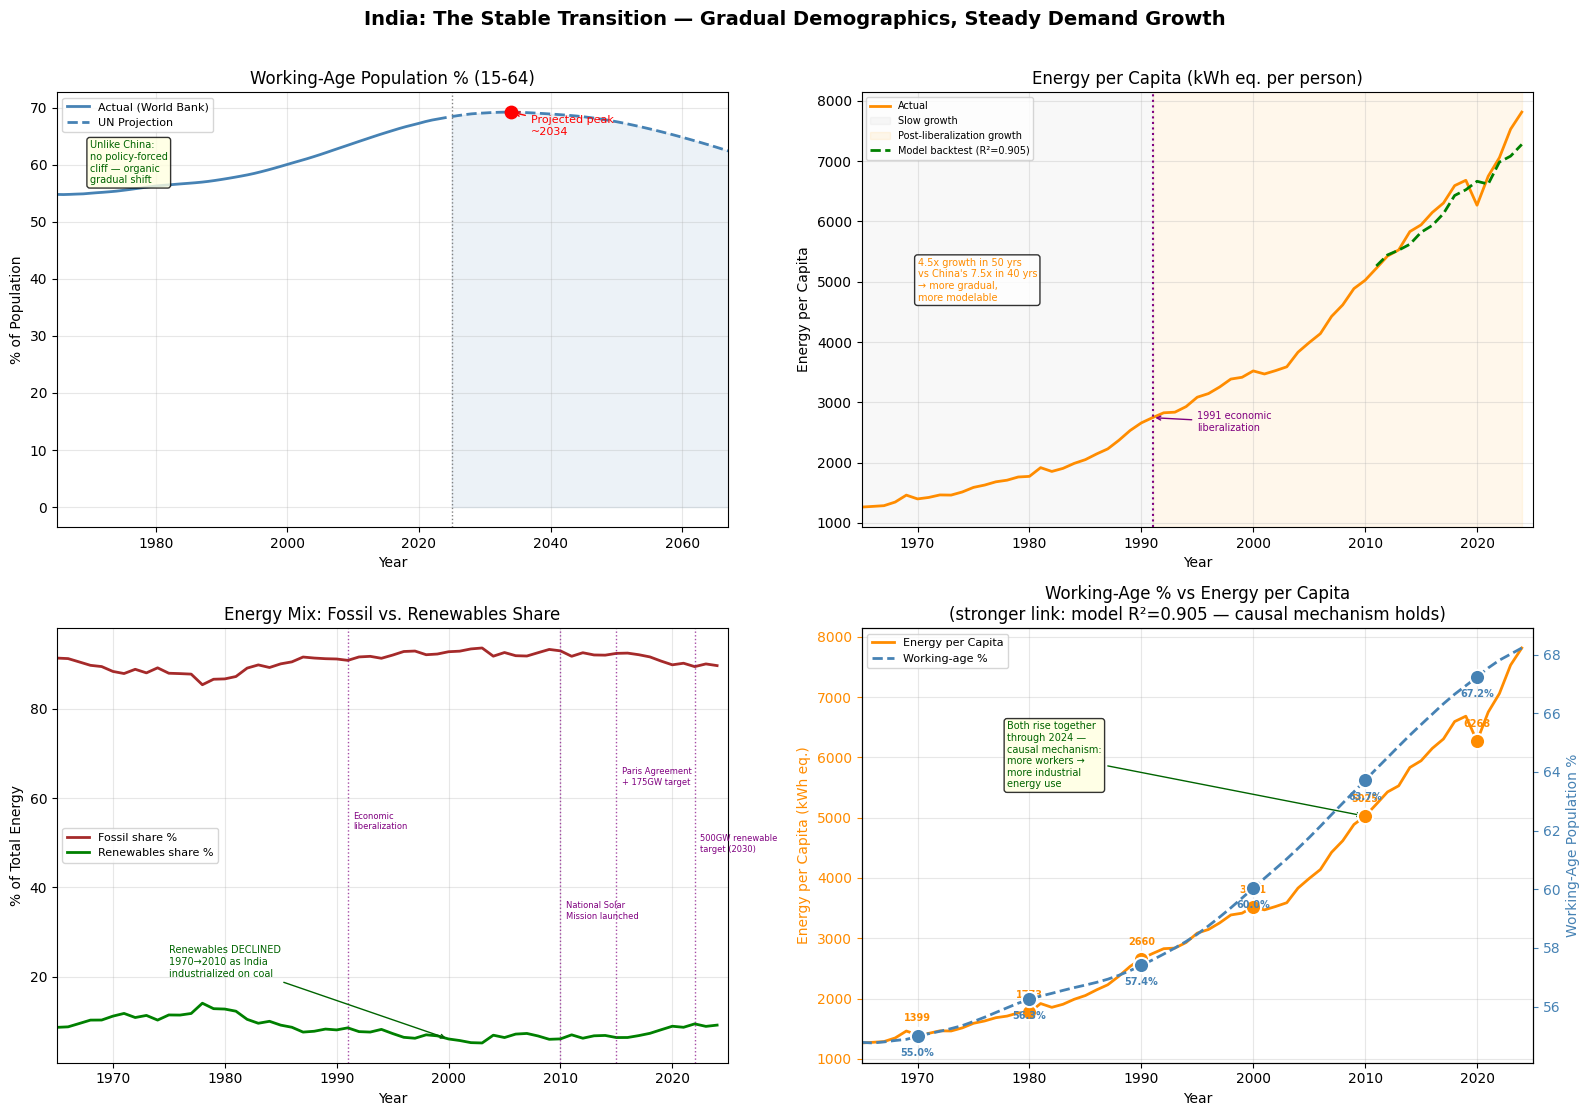

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

india = actuals_final[actuals_final["country_code"] == "IND"].sort_values("year")
india_proj = age_clean[age_clean["country_code"] == "IND"].sort_values("year")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("India: The Stable Transition — Gradual Demographics, Steady Demand Growth",
             fontsize=14, fontweight="bold", y=1.01)


# Panel 1: Working-age population — still rising, not peaked
ax = axes[0, 0]
ax.plot(india["year"], india["pop_working_age_pct"],
        color="steelblue", linewidth=2, label="Actual (World Bank)")

proj_filtered = india_proj[india_proj["year"] > 2024]
ax.plot(proj_filtered["year"], proj_filtered["pop_working_age_pct"],
        color="steelblue", linewidth=2, linestyle="--", label="UN Projection")

ax.fill_between(proj_filtered["year"], proj_filtered["pop_working_age_pct"],
                alpha=0.1, color="steelblue")
ax.axvline(x=2025, color="gray", linestyle=":", linewidth=1)

# Find projected working-age peak
peak_idx = india_proj[india_proj["year"] > 2024]["pop_working_age_pct"].idxmax()
peak_year_wa = india_proj.loc[peak_idx, "year"]
peak_val_wa = india_proj.loc[peak_idx, "pop_working_age_pct"]
ax.scatter([peak_year_wa], [peak_val_wa], color="red", s=80, zorder=5)
ax.annotate(f"Projected peak\n~{int(peak_year_wa)}",
            xy=(peak_year_wa, peak_val_wa),
            xytext=(peak_year_wa + 3, peak_val_wa - 4),
            fontsize=8, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

# Contrast with China annotation
ax.text(1970, india["pop_working_age_pct"].min() + 2,
        "Unlike China:\nno policy-forced\ncliff — organic\ngradual shift",
        fontsize=7, color="darkgreen",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

ax.set_title("Working-Age Population % (15-64)")
ax.set_xlabel("Year")
ax.set_ylabel("% of Population")
ax.set_xlim(1965, 2067)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Panel 2: Energy per capita — steady, not explosive
ax = axes[0, 1]
ax.plot(india["year"], india["energy_per_capita"],
        color="darkorange", linewidth=2, label="Actual")

# Shade phases — different from China's, no explosive jump
ax.axvspan(1965, 1991, alpha=0.05, color="gray", label="Slow growth")
ax.axvspan(1991, 2024, alpha=0.08, color="orange", label="Post-liberalization growth")

# Annotate the 1991 economic liberalization
ax.axvline(x=1991, color="purple", linestyle=":", linewidth=1.5)
ax.annotate("1991 economic\nliberalization",
            xy=(1991, india[india["year"] == 1991]["energy_per_capita"].values[0]),
            xytext=(1995, india["energy_per_capita"].dropna().min() * 2),
            fontsize=7, color="purple",
            arrowprops=dict(arrowstyle="->", color="purple"))

# Contrast with China
ax.text(1970, india["energy_per_capita"].dropna().max() * 0.6,
        "4.5x growth in 50 yrs\nvs China's 7.5x in 40 yrs\n→ more gradual,\nmore modelable",
        fontsize=7, color="darkorange",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add backtested model line
test_years_ind = country_results["IND"]["test_years"]
test_pred_ind = country_results["IND"]["y_pred"]
ax.plot(test_years_ind, test_pred_ind, color="green", linewidth=2,
        linestyle="--", label=f"Model backtest (R²=0.905)")

ax.set_title("Energy per Capita (kWh eq. per person)")
ax.set_xlabel("Year")
ax.set_ylabel("Energy per Capita")
ax.set_xlim(1965, 2025)
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)


# Panel 3: Fossil vs Renewables — the development trap story
ax = axes[1, 0]
ax.plot(india["year"], india["fossil_share_energy"],
        color="brown", linewidth=2, label="Fossil share %")
ax.plot(india["year"], india["renewables_share_energy"],
        color="green", linewidth=2, label="Renewables share %")

# Annotate the renewables dip — the most interesting feature
ax.annotate("Renewables DECLINED\n1970→2010 as India\nindustrialized on coal",
            xy=(2000, india[india["year"] == 2000]["renewables_share_energy"].values[0]),
            xytext=(1975, 20),
            fontsize=7, color="darkgreen",
            arrowprops=dict(arrowstyle="->", color="darkgreen"))

# Mark key policy events
events = {
    1991: ("Economic\nliberalization", 50),
    2010: ("National Solar\nMission launched", 30),
    2015: ("Paris Agreement\n+ 175GW target", 60),
    2022: ("500GW renewable\ntarget (2030)", 45),
}
for year, (label, ypos) in events.items():
    ax.axvline(x=year, color="purple", linestyle=":", linewidth=1, alpha=0.7)
    ax.annotate(label, xy=(year, ypos), xytext=(year + 0.5, ypos + 3),
                fontsize=6, color="purple")

ax.set_title("Energy Mix: Fossil vs. Renewables Share")
ax.set_xlabel("Year")
ax.set_ylabel("% of Total Energy")
ax.set_xlim(1965, 2025)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Panel 4: Aging vs renewables scatter — green shades
# Panel 4 replacement for BOTH India and China charts
# Working-age % vs Energy per Capita — dual axis time series

# ---- INDIA VERSION ----
ax = axes[1, 1]
india_clean = india.dropna(subset=["pop_working_age_pct", "energy_per_capita"])

ax2 = ax.twinx()

line1, = ax.plot(india_clean["year"], india_clean["energy_per_capita"],
                 color="darkorange", linewidth=2, label="Energy per Capita")
line2, = ax2.plot(india_clean["year"], india_clean["pop_working_age_pct"],
                  color="steelblue", linewidth=2, linestyle="--", label="Working-age %")

# Decade markers with values
decade_rows = india_clean[india_clean["year"] % 10 == 0]
for _, row in decade_rows.iterrows():
    ax.scatter(row["year"], row["energy_per_capita"],
               color="darkorange", s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(f"{row['energy_per_capita']:.0f}",
                xy=(row["year"], row["energy_per_capita"]),
                xytext=(0, 10), textcoords="offset points",
                fontsize=7, color="darkorange", ha="center", fontweight="bold")

    ax2.scatter(row["year"], row["pop_working_age_pct"],
                color="steelblue", s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax2.annotate(f"{row['pop_working_age_pct']:.1f}%",
                 xy=(row["year"], row["pop_working_age_pct"]),
                 xytext=(0, -14), textcoords="offset points",
                 fontsize=7, color="steelblue", ha="center", fontweight="bold")

# Annotate the relationship
ax.annotate("Both rise together\nthrough 2024 —\ncausal mechanism:\nmore workers →\nmore industrial\nenergy use",
            xy=(2010, india_clean[india_clean["year"] == 2010]["energy_per_capita"].values[0]),
            xytext=(1978, 5500),
            fontsize=7, color="darkgreen",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
            arrowprops=dict(arrowstyle="->", color="darkgreen"))

# Mark working-age peak (projected)
ax2.axvline(x=2034, color="red", linestyle=":", linewidth=1.5)
ax2.annotate("Working-age\npeak ~2034",
             xy=(2034, india_clean["pop_working_age_pct"].max()),
             xytext=(2018, india_clean["pop_working_age_pct"].max() - 3),
             fontsize=7, color="red",
             arrowprops=dict(arrowstyle="->", color="red"))

ax.set_ylabel("Energy per Capita (kWh eq.)", color="darkorange")
ax2.set_ylabel("Working-Age Population %", color="steelblue")
ax.tick_params(axis="y", colors="darkorange")
ax2.tick_params(axis="y", colors="steelblue")
ax.set_title("Working-Age % vs Energy per Capita\n(stronger link: model R²=0.905 — causal mechanism holds)")
ax.set_xlabel("Year")
ax.set_xlim(1965, 2025)
ax.grid(alpha=0.3)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("india_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

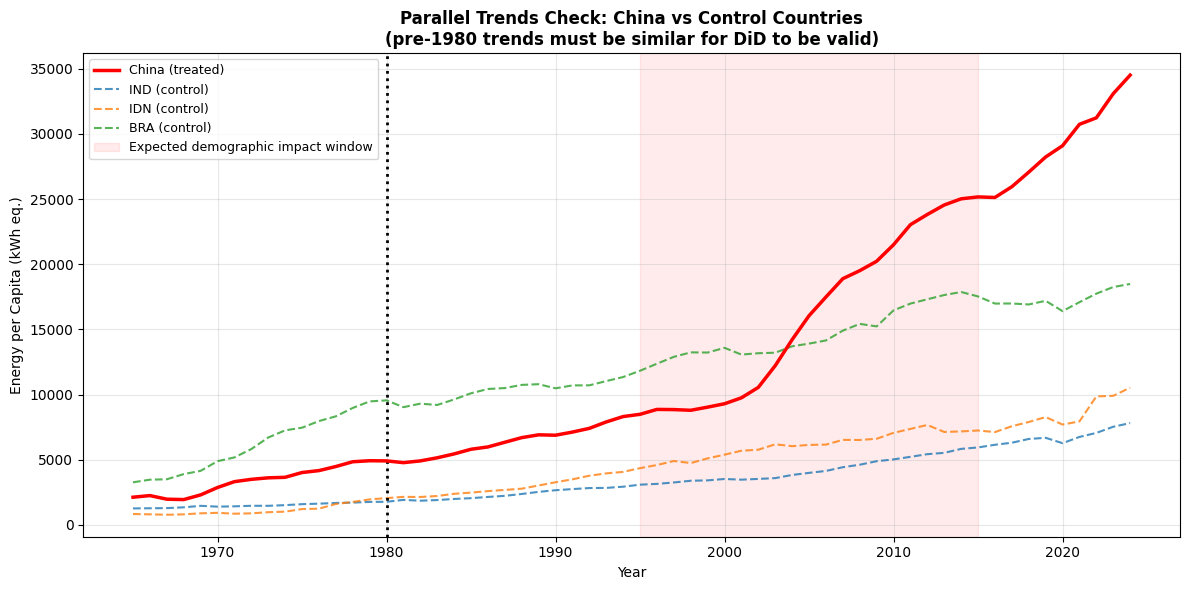

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

actuals_final = pd.read_csv("actuals_final.csv")

# Check pre-1980 energy per capita trends for China vs controls
controls = ["IND", "IDN", "BRA"]
treatment = "CHN"

fig, ax = plt.subplots(figsize=(12, 6))

china = actuals_final[actuals_final["country_code"] == "CHN"].dropna(subset=["energy_per_capita"])
ax.plot(china["year"], china["energy_per_capita"],
        color="red", linewidth=2.5, label="China (treated)", zorder=5)

for code in controls:
    ctrl = actuals_final[actuals_final["country_code"] == code].dropna(subset=["energy_per_capita"])
    ax.plot(ctrl["year"], ctrl["energy_per_capita"],
            linewidth=1.5, linestyle="--", label=f"{code} (control)", alpha=0.8)

# Mark the policy introduction
ax.axvline(x=1980, color="black", linestyle=":", linewidth=2)
ax.annotate("One-child policy\nintroduced (1980)",
            xy=(1980, actuals_final["energy_per_capita"].max() * 0.5),
            xytext=(1983, actuals_final["energy_per_capita"].max() * 0.5),
            fontsize=9, color="black",
            arrowprops=dict(arrowstyle="->", color="black"))

# Mark the demographic impact window (15-20 years after policy)
ax.axvspan(1995, 2015, alpha=0.08, color="red", label="Expected demographic impact window")

ax.set_title("Parallel Trends Check: China vs Control Countries\n(pre-1980 trends must be similar for DiD to be valid)",
             fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Energy per Capita (kWh eq.)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("parallel_trends_check.png", dpi=150, bbox_inches="tight")
plt.show()

In [2]:
# Synthetic control: find weights for IND, IDN, BRA that best
# reproduce China's pre-1980 energy per capita trajectory
import numpy as np
from scipy.optimize import minimize

pre_period = actuals_final[actuals_final["year"] < 1980].dropna(subset=["energy_per_capita"])

china_pre = pre_period[pre_period["country_code"] == "CHN"]["energy_per_capita"].values
ind_pre = pre_period[pre_period["country_code"] == "IND"]["energy_per_capita"].values
idn_pre = pre_period[pre_period["country_code"] == "IDN"]["energy_per_capita"].values
bra_pre = pre_period[pre_period["country_code"] == "BRA"]["energy_per_capita"].values

# Make sure all same length
min_len = min(len(china_pre), len(ind_pre), len(idn_pre), len(bra_pre))
china_pre = china_pre[:min_len]
controls_pre = np.column_stack([ind_pre[:min_len], idn_pre[:min_len], bra_pre[:min_len]])

# Find weights that minimize difference between synthetic and actual China pre-1980
def objective(weights):
    synthetic = controls_pre @ weights
    return np.sum((china_pre - synthetic) ** 2)

# Constraints: weights sum to 1, all positive
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * 3
result = minimize(objective, [1/3, 1/3, 1/3], method="SLSQP",
                  bounds=bounds, constraints=constraints)
weights = result.x

print(f"Synthetic control weights:")
print(f"  India:     {weights[0]:.3f}")
print(f"  Indonesia: {weights[1]:.3f}")
print(f"  Brazil:    {weights[2]:.3f}")
print(f"Pre-1980 fit (lower = better): {result.fun:.2f}")

Synthetic control weights:
  India:     0.286
  Indonesia: 0.286
  Brazil:    0.428
Pre-1980 fit (lower = better): 598589.84
